# User Behavior Funnel Analysis

## Objective
Analyze user behavior across the marketing funnel to identify drop-off points and improve conversion performance.

## Skills Demonstrated
- Data processing workflow (load → clean → transform → aggregate)
- KPI definition and business analysis
- SQL-style aggregation
- Data validation and quality checks
- Data visualization

## 1. Data Understanding
This dataset contains event-level user interactions with ads.

Key event types:
- **Impression**: user views the ad
- **Click**: user interacts with the ad
- **Purchase**: treated as conversion event
- **Like / Share / Comment**: engagement signals

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df = pd.read_csv("ad_events.csv")
df.head()

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression


## 2. Data Overview
Initial inspection of dataset structure and summary statistics.

In [55]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   event_id     400000 non-null  int64 
 1   ad_id        400000 non-null  int64 
 2   user_id      400000 non-null  object
 3   timestamp    400000 non-null  object
 4   day_of_week  400000 non-null  object
 5   time_of_day  400000 non-null  object
 6   event_type   400000 non-null  object
dtypes: int64(2), object(5)
memory usage: 21.4+ MB


,event_id,ad_id
count,400000.000000,400000.000000
mean,200000.500000,100.535965
std,115470.198175,57.775915
min,1.000000,1.000000
25%,100000.750000,51.000000
50%,200000.500000,101.000000
75%,300000.250000,151.000000
max,400000.000000,200.000000


## 3. Data Quality Check
Checking for missing values and data consistency.

In [112]:
df.isnull().sum()

event_id       0
ad_id          0
user_id        0
timestamp      0
day_of_week    0
time_of_day    0
event_type     0
dtype: int64

## 4. Data Preparation
Cleaning dataset to ensure consistency.

In [64]:
df = df.dropna()

## 5. Metric Definition

We define key funnel metrics based on event counts.

In [116]:
funnel_counts = df['event_type'].value_counts()

impressions = funnel_counts.get('Impression', 0)
clicks = funnel_counts.get('Click', 0)
purchases = funnel_counts.get('Purchase', 0)

engagement = (
    funnel_counts.get('Like', 0) +
    funnel_counts.get('Share', 0) +
    funnel_counts.get('Comment', 0)
)

print("Impressions:", impressions)
print("Clicks:", clicks)
print("Purchases:", purchases)
print("Engagement:", engagement)

Impressions: 339812
Clicks: 40079
Purchases: 2031
Engagement: 18078


In [118]:
ctr = clicks / impressions if impressions != 0 else 0
purchase_rate = purchases / impressions if impressions != 0 else 0
conversion_rate = purchases / clicks if clicks != 0 else 0

print("CTR:", ctr)
print("Purchase Rate:", purchase_rate)
print("Conversion Rate:", conversion_rate)

CTR: 0.11794462820618459
Purchase Rate: 0.005976834249526209
Conversion Rate: 0.05067491703884827


## 6. Funnel Visualization
Visualizing user progression through the funnel.

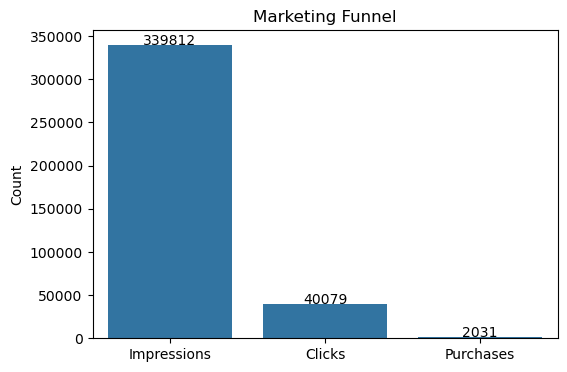

In [121]:
stages = ['Impressions', 'Clicks', 'Purchases']
values = [impressions, clicks, purchases]

plt.figure(figsize=(6,4))
sns.barplot(x=stages, y=values)

for i, v in enumerate(values):
    plt.text(i, v, str(v), ha='center')

plt.title("Marketing Funnel")
plt.ylabel("Count")
plt.show()

## 7. Event Distribution
Understanding overall user activity types.

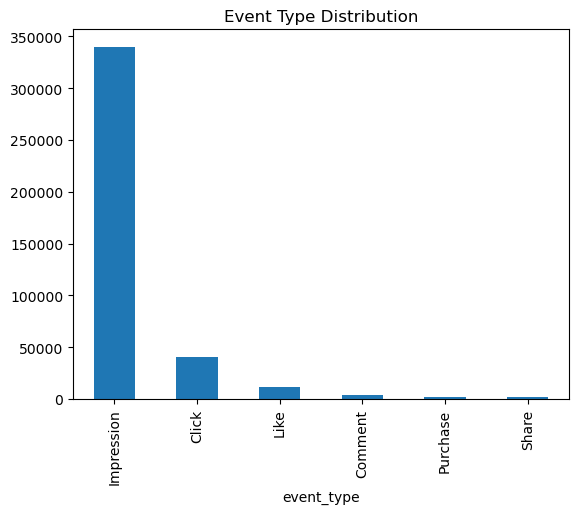

In [124]:
df['event_type'].value_counts().plot(kind='bar')
plt.title("Event Type Distribution")
plt.show()

### Engagement Funnel
User engagement beyond clicks.

In [99]:
engagement = funnel_counts.get('Like', 0) + \
             funnel_counts.get('Share', 0) + \
             funnel_counts.get('Comment', 0)

print("Engagement:", engagement)

Engagement: 18078


## 8. Key Insights

- Only a small percentage of impressions convert into clicks, indicating weak top-of-funnel engagement
- Purchase rate is extremely low, suggesting significant drop-off in final conversion stage
- Engagement actions (likes, shares, comments) indicate user interest but not strong purchase intent

## 9. Business Recommendations

- Improve ad targeting or creatives to increase CTR
- Optimize landing experience to improve conversion rates
- Use engagement signals (likes, shares) for retargeting strategies